In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.svm import SVR 
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score

In [15]:
# Caminho para o dataset
dataset_path = 'C:\\Users\\noturno\\Desktop\\Machine-Learning\\Exercícios de classificação e regressão usando dados reais\\bem_candidato_2022_AM.csv'

In [17]:
# Carregar o dataset
df = pd.read_csv(dataset_path, sep=';', encoding='ISO-8859-1')

In [19]:
# Verificar e tratar valores nulos
print("\nValores nulos no dataset:")
print(df.isnull().sum())


Valores nulos no dataset:
DT_GERACAO                    0
HH_GERACAO                    0
ANO_ELEICAO                   0
CD_TIPO_ELEICAO               0
NM_TIPO_ELEICAO               0
CD_ELEICAO                    0
DS_ELEICAO                    0
DT_ELEICAO                    0
SG_UF                         0
SG_UE                         0
NM_UE                         0
SQ_CANDIDATO                  0
NR_ORDEM_BEM_CANDIDATO        0
CD_TIPO_BEM_CANDIDATO         0
DS_TIPO_BEM_CANDIDATO         0
DS_BEM_CANDIDATO              0
VR_BEM_CANDIDATO              0
DT_ULT_ATUAL_BEM_CANDIDATO    0
HH_ULT_ATUAL_BEM_CANDIDATO    0
dtype: int64


In [21]:
# Remover ou imputar valores nulos
df = df.dropna(subset=['VR_BEM_CANDIDATO', 'DT_ULT_ATUAL_BEM_CANDIDATO', 'DT_ELEICAO'])

In [23]:
# Convertendo a coluna 'VR_BEM_CANDIDATO' para valores numéricos
df['VR_BEM_CANDIDATO'] = df['VR_BEM_CANDIDATO'].str.replace(',', '.')  # Substitui vírgulas por pontos
df['VR_BEM_CANDIDATO'] = pd.to_numeric(df['VR_BEM_CANDIDATO'], errors='coerce')

In [25]:
# Convertendo as colunas de data para numéricas (dias desde a data mínima)
date_columns = ['DT_ULT_ATUAL_BEM_CANDIDATO', 'DT_ELEICAO']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')  # Converte para datetime
    df[col] = (df[col] - df[col].min()) / pd.Timedelta(days=1)

In [27]:
# Convertendo as colunas de data para numéricas (dias desde a data mínima)
date_columns = ['DT_ULT_ATUAL_BEM_CANDIDATO', 'DT_ELEICAO']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')  # Converte para datetime
    df[col] = (df[col] - df[col].min()) / pd.Timedelta(days=1)

In [29]:
# Variáveis independentes (entradas)
X = df[['DT_ULT_ATUAL_BEM_CANDIDATO', 'DT_ELEICAO']]  # Seleciona apenas as colunas de data
y = df['VR_BEM_CANDIDATO']

In [31]:
# Imputação de valores ausentes (se necessário)
imputer = SimpleImputer(strategy='mean')  # Preenche valores ausentes com a média
X_imputed = imputer.fit_transform(X)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

In [35]:
models = {
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100),
    "HistGradientBoosting Regressor": HistGradientBoostingRegressor(),
    "Support Vector Regressor": SVR()
}

In [37]:
# Treinando e avaliando os modelos
for name, model in models.items():
    print(f"\nTreinando o modelo: {name}")
    
    # Treinando o modelo
    model.fit(X_train, y_train)
    
    # Realizando previsões
    y_pred = model.predict(X_test)
    
    # Avaliando o desempenho do modelo
    mse = mean_squared_error(y_test, y_pred)
    print(f"Erro quadrático médio para {name}: {mse}")


Treinando o modelo: Random Forest Regressor
Erro quadrático médio para Random Forest Regressor: 108175846005.91833

Treinando o modelo: HistGradientBoosting Regressor
Erro quadrático médio para HistGradientBoosting Regressor: 109122514477.74037

Treinando o modelo: Support Vector Regressor
Erro quadrático médio para Support Vector Regressor: 119856267207.67825


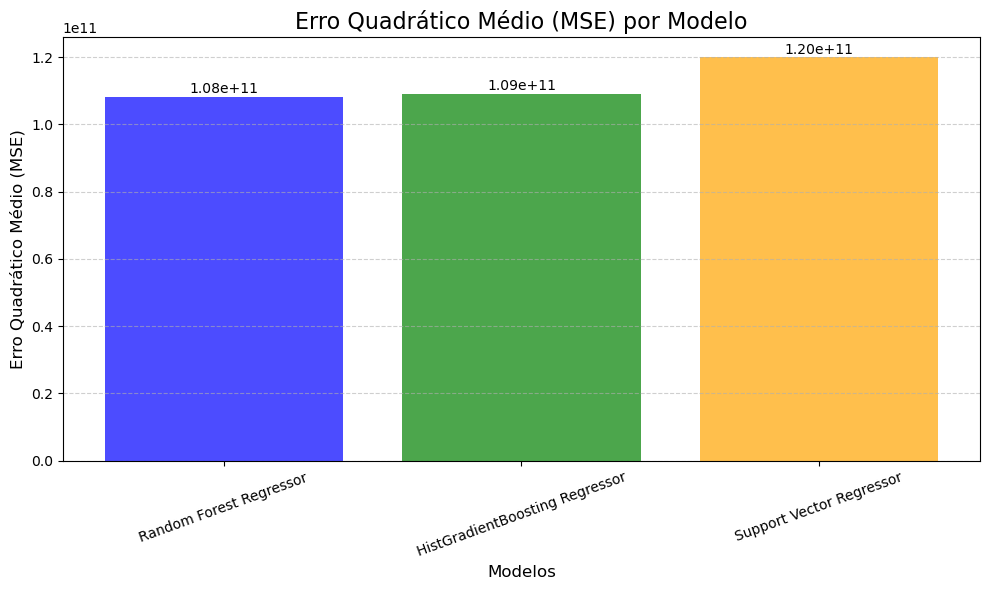

In [41]:
import matplotlib.pyplot as plt

# Dados dos modelos e seus respectivos erros quadráticos médios
model_names = [
    "Random Forest Regressor", 
    "HistGradientBoosting Regressor", 
    "Support Vector Regressor"
]
mse_values = [
    108175846005.91833, 
    109122514477.74037, 
    119856267207.67825
]

# Criando o gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(model_names, mse_values, color=['blue', 'green', 'orange'], alpha=0.7)

# Adicionando rótulos e título
plt.title("Erro Quadrático Médio (MSE) por Modelo", fontsize=16)
plt.ylabel("Erro Quadrático Médio (MSE)", fontsize=12)
plt.xlabel("Modelos", fontsize=12)

# Adicionando os valores do MSE acima das barras
for i, mse in enumerate(mse_values):
    plt.text(i, mse + 1e9, f"{mse:.2e}", ha='center', fontsize=10)

# Ajustando o layout e exibindo o gráfico
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()